In [ ]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

RANDOM_SEED = 42

# 各パス指定

In [2]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'

# 分類数設定

In [ ]:
import csv

label_path = 'model/keypoint_classifier/keypoint_classifier_label.csv'

with open(label_path, newline='', encoding='utf-8-sig') as f:
    labels = [row[0] for row in csv.reader(f) if row and row[0] != '']

NUM_CLASSES = len(labels)
print(f'Detected {NUM_CLASSES} classes from {label_path}: {labels}')

Detected 10 classes from model/keypoint_classifier/keypoint.csv


# 学習データ読み込み

In [4]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [5]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [ ]:
original_classes = np.unique(y_dataset)
valid_class_ids = np.arange(NUM_CLASSES, dtype=np.int32)
dataset_mask = np.isin(y_dataset, valid_class_ids)
removed_classes = sorted(set(original_classes.tolist()) - set(valid_class_ids.tolist()))

X_dataset = X_dataset[dataset_mask]
y_dataset = y_dataset[dataset_mask]

print(f'Filtered dataset to {len(y_dataset)} samples across {NUM_CLASSES} classes.')
if removed_classes:
    print(f'Removed unlabeled classes: {removed_classes}')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_dataset,
    y_dataset,
    train_size=0.75,
    random_state=RANDOM_SEED,
    stratify=y_dataset,
)

In [ ]:
def augment_landmark_sample(sample, rotation_deg=20.0, noise_std=0.01):
    points = np.asarray(sample, dtype=np.float32).reshape(-1, 2)
    angle = np.deg2rad(np.random.uniform(-rotation_deg, rotation_deg))
    rotation = np.array(
        [[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]],
        dtype=np.float32,
    )
    transformed = points @ rotation.T
    transformed += np.random.normal(0.0, noise_std, transformed.shape).astype(np.float32)
    return np.clip(transformed, -1.5, 1.5).reshape(-1)


def augment_training_data(X, y, copies=2):
    augmented_x = [X.astype(np.float32)]
    augmented_y = [y.astype(np.int32)]

    for _ in range(copies):
        transformed_x = np.array([augment_landmark_sample(sample) for sample in X], dtype=np.float32)
        augmented_x.append(transformed_x)
        augmented_y.append(y.astype(np.int32))

    return np.vstack(augmented_x), np.concatenate(augmented_y)


X_train_aug, y_train_aug = augment_training_data(X_train, y_train, copies=2)
class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_aug),
    y=y_train_aug,
)
class_weight = dict(zip(np.unique(y_train_aug), class_weight_values))

print(f'Augmented training set: {X_train_aug.shape[0]} samples')
print('Class weight:', class_weight)

# モデル構築

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [8]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dropout (Dropout)           (None, 42)                0         


 dense (Dense)               (None, 20)                860       


...

 dense_2 (Dense)             (None, 10)                110       


Total params: 1180 (4.61 KB)


Trainable params: 1180 (4.61 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


In [ ]:
# モデルチェックポイントのコールバック
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path,
    verbose=1,
    save_weights_only=False,
    monitor='val_accuracy',
    save_best_only=True,
)
# 早期打ち切り用コールバック
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=50,
    restore_best_weights=True,
    verbose=1,
)
# 学習率減衰用コールバック
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=15,
    min_lr=1e-5,
    verbose=1,
)

In [ ]:
# モデルコンパイル
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# モデル訓練

In [ ]:
model.fit(
    X_train_aug,
    y_train_aug,
    epochs=2000,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback, lr_callback],
    class_weight=class_weight,
)

Epoch 1/1000



  1/115 [..............................] - ETA: 1:01 - loss: 2.5678 - accuracy: 0.0938


 46/115 [===========>..................] - ETA: 0s - loss: 2.3907 - accuracy: 0.1325  


 91/115 [======================>.......] - ETA: 0s - loss: 2.3452 - accuracy: 0.1361


Epoch 1: saving model to model/keypoint_classifier\keypoint_classifier.hdf5


...


 49/115 [===========>..................] - ETA: 0s - loss: 1.4148 - accuracy: 0.4853


 93/115 [=======================>......] - ETA: 0s - loss: 1.4284 - accuracy: 0.4831


Epoch 89: saving model to model/keypoint_classifier\keypoint_classifier.hdf5



115/115 [==============================] - 0s 2ms/step - loss: 1.4317 - accuracy: 0.4831 - val_loss: 1.2222 - val_accuracy: 0.5872


Epoch 89: early stopping


In [12]:
# モデル評価
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)


 1/39 [..............................] - ETA: 0s - loss: 1.0744 - accuracy: 0.6953


39/39 [==============================] - 0s 751us/step - loss: 1.2222 - accuracy: 0.5872


In [13]:
# 保存したモデルのロード
model = tf.keras.models.load_model(model_save_path)

In [14]:
# 推論テスト
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))


1/1 [==============================] - ETA: 0s


1/1 [==============================] - 0s 60ms/step


[2.5700232e-02 6.8985367e-01 1.4481853e-02 3.7521069e-04 1.1822477e-01
 8.3658546e-02 6.0549818e-02 1.6029591e-04 2.8562199e-03 4.1393689e-03]
1


# 混同行列


  1/153 [..............................] - ETA: 2s


 73/153 [=============>................] - ETA: 0s


148/153 [============================>.] - ETA: 0s


153/153 [==============================] - 0s 702us/step


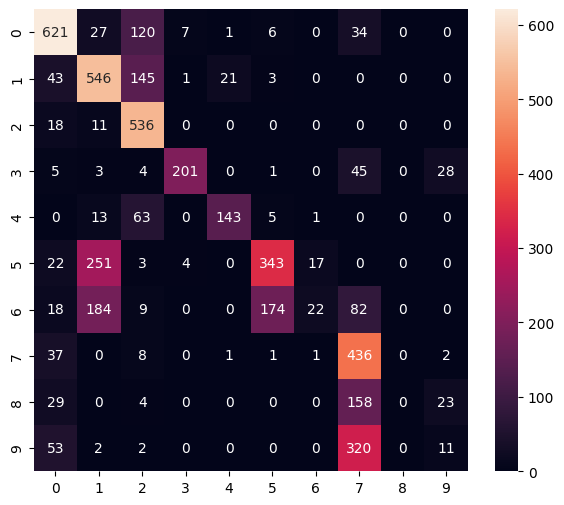

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.76      0.75       816
           1       0.53      0.72      0.61       759
           2       0.60      0.95      0.73       565
           3       0.94      0.70      0.80       287
           4       0.86      0.64      0.73       225
           5       0.64      0.54      0.58       640
           6       0.54      0.04      0.08       489
           7       0.41      0.90      0.56       486
           8       0.00      0.00      0.00       214
           9       0.17      0.03      0.05       388

    accuracy                           0.59      4869
   macro avg       0.54      0.53      0.49      4869
weighted avg       0.56      0.59      0.53      4869



E:\licenta\hand-gesture-recognition-mediapipe\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
E:\licenta\hand-gesture-recognition-mediapipe\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
E:\licenta\hand-gesture-recognition-mediapipe\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Tensorflow-Lite用のモデルへ変換

In [16]:
# 推論専用のモデルとして保存
model.save(model_save_path, include_optimizer=False)

E:\licenta\hand-gesture-recognition-mediapipe\venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [17]:
# モデルを変換(量子化)
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\This\AppData\Local\Temp\tmp398enujg\assets


INFO:tensorflow:Assets written to: C:\Users\This\AppData\Local\Temp\tmp398enujg\assets


6824

# 推論テスト

In [18]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [19]:
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print('Input details:', input_details)
print('Output details:', output_details)

Input details: [{'name': 'serving_default_input_1:0', 'index': 0, 'shape': array([ 1, 42]), 'shape_signature': array([-1, 42]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall:0', 'index': 10, 'shape': array([ 1, 10]), 'shape_signature': array([-1, 10]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


In [20]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]], dtype=np.float32))
print('Input tensor set')

Input tensor set


In [21]:
# Run inference
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])
print('Inference completed')
print('Prediction vector:', np.squeeze(tflite_results))
print('Predicted class:', int(np.argmax(np.squeeze(tflite_results))))

Inference completed
Prediction vector: [2.5700253e-02 6.8985361e-01 1.4481868e-02 3.7521045e-04 1.1822483e-01
 8.3658516e-02 6.0549799e-02 1.6029589e-04 2.8562197e-03 4.1393684e-03]
Predicted class: 1


In [22]:
print('TFLite inference finished successfully')

TFLite inference finished successfully
